In [3]:
import pandas as pd
import numpy as np

# Read dataset
df = pd.read_csv("Dataset_Day9.csv")

# Replace 0 with NaN
cols = ['Glucose', 'BloodPressure', 'BMI',
        'DiabetesPedigreeFunction', 'Age']

for col in cols:
    df[col] = df[col].replace(0, np.nan)

# Fill missing values using median
for col in cols:
    df[col] = df[col].fillna(df[col].median())

# Remove outliers using IQR method
for col in cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(df.head())
print(df.shape)

   Pregnancies  Glucose  BloodPressure   BMI  DiabetesPedigreeFunction  Age  \
0            6    148.0           72.0  33.6                     0.627   50   
1            1     85.0           66.0  26.6                     0.351   31   
2            8    183.0           64.0  23.3                     0.672   32   
3            1     89.0           66.0  28.1                     0.167   21   
5            5    116.0           74.0  25.6                     0.201   30   

   Outcome  
0        1  
1        0  
2        1  
3        0  
5        0  
(706, 7)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Predictor variables
X = df.drop('Outcome', axis=1)

# Target variable
y = df['Outcome']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=1234
)

# Train SVM model
model = SVC()

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Performance metrics
print("Accuracy =", accuracy_score(y_test, y_pred))
print("Precision =", precision_score(y_test, y_pred))
print("Recall =", recall_score(y_test, y_pred))
print("F1 Score =", f1_score(y_test, y_pred))

Accuracy = 0.8305084745762712
Precision = 0.9459459459459459
Recall = 0.5555555555555556
F1 Score = 0.7


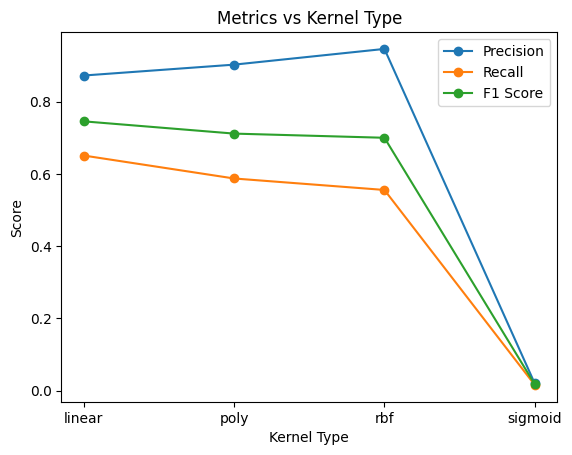

Best Kernel = linear


In [5]:
import matplotlib.pyplot as plt

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
C_values = [0.001, 0.01, 0.1, 1, 10]

precision_list = []
recall_list = []
f1_list = []

for kernel in kernels:

    model = SVC(kernel=kernel, C=1)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    precision_list.append(precision_score(y_test, y_pred))
    recall_list.append(recall_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred))


# Plot graph
plt.plot(kernels, precision_list, marker='o', label='Precision')
plt.plot(kernels, recall_list, marker='o', label='Recall')
plt.plot(kernels, f1_list, marker='o', label='F1 Score')

plt.xlabel("Kernel Type")
plt.ylabel("Score")
plt.title("Metrics vs Kernel Type")

plt.legend()
plt.show()

# Best kernel
best_kernel = kernels[f1_list.index(max(f1_list))]

print("Best Kernel =", best_kernel)

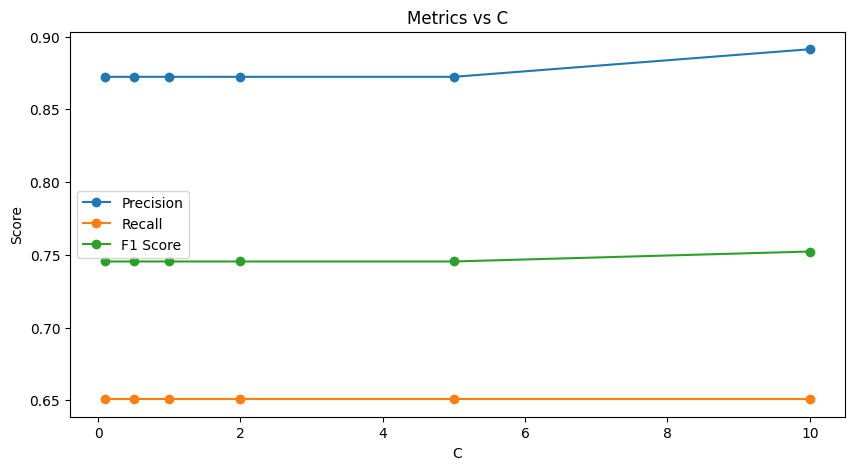

Best C = 10


In [6]:
# Different values of C to test
C_range = [0.1, 0.5, 1, 2, 5, 10]

# Lists to store metrics
precision_list = []
recall_list = []
f1_list = []

# Train and evaluate model for each C value
for c in C_range:

    # Create SVM model using the best kernel found in Problem 3(b)
    model = SVC(kernel=best_kernel, C=c)

    # Train the model
    model.fit(X_train, y_train)

    # Predict on test data
    y_pred = model.predict(X_test)

    # Store performance metrics
    precision_list.append(precision_score(y_test, y_pred))
    recall_list.append(recall_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred))


# Plot graph
plt.figure(figsize=(10,5))

plt.plot(C_range, precision_list, marker='o', label='Precision')
plt.plot(C_range, recall_list, marker='o', label='Recall')
plt.plot(C_range, f1_list, marker='o', label='F1 Score')

plt.xlabel("C")
plt.ylabel("Score")
plt.title("Metrics vs C")

plt.legend()
plt.show()


# Find the best value of C
best_C = C_range[f1_list.index(max(f1_list))]

print("Best C =", best_C)